# FASE 6 V3: SVC direccional con horizonte mensual (BVG)

Objetivo:
- Redefinir el problema para buscar senal mas robusta en un mercado iliquido.
- Priorizar calidad de senal y defensa metodologica sobre metricas infladas.
- Usar solo informacion disponible desde 2023 en adelante.

## 1) Diseno experimental

Decisiones clave:
- Horizonte mensual aproximado: 20 dias habiles (t+20).
- Target con umbral de significancia para reducir ruido:
  - y=1 si retorno futuro acumulado > +0.003
  - y=0 si retorno futuro acumulado < -0.003
  - Se eliminan observaciones intermedias (zona de baja senal).
- Split temporal 70/30 (sin random split).
- Walk-forward simple como chequeo de consistencia.
- Comparacion obligatoria contra baselines fuertes.

In [1]:
# 2) Librerias
import importlib
import subprocess
import sys
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

if importlib.util.find_spec('sklearn') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'scikit-learn'])
if importlib.util.find_spec('datasets') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'datasets'])

from datasets import load_dataset
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.svm import SVC

pd.set_option('display.max_columns', 220)
pd.set_option('display.width', 260)
sns.set_theme(style='whitegrid')

c:\Users\leynd\OneDrive\Escritorio\Tesis\implementaciones\desarrollov2\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2) Carga de datos y filtro temporal (2023+)

In [2]:
def canonical_col(name):
    txt = unicodedata.normalize('NFKD', str(name))
    txt = ''.join(ch for ch in txt if ord(ch) < 128)
    return txt.upper().strip()

def find_col(columns, expected):
    cmap = {canonical_col(c): c for c in columns}
    for key in expected:
        if key in cmap:
            return cmap[key]
    for c in columns:
        ccan = canonical_col(c)
        for key in expected:
            if key in ccan:
                return c
    raise KeyError(f'No se encontro columna para {expected}')

def load_raw_df():
    local_path = Path('papers') / 'BVG_Acciones_export.csv'
    if local_path.exists():
        return pd.read_csv(local_path, low_memory=False), 'csv_local'
    ds = load_dataset('beta3/Historical_Data_of_Ecuador_Stock_Exchange', 'default_stocks')
    return ds['stocks'].to_pandas(), 'huggingface_default_stocks'

df_raw, data_source = load_raw_df()
print('Fuente:', data_source)
print('Shape raw:', df_raw.shape)

emisor_col = find_col(df_raw.columns, ['EMISOR'])
fecha_col = find_col(df_raw.columns, ['FECHA NEGOCIACION', 'FECHA'])
precio_col = find_col(df_raw.columns, ['PRECIO', 'CLOSE'])

empresas_objetivo = ['CORPORACION FAVORITA C.A.', 'BANCO GUAYAQUIL S.A.']
empresas_can = [canonical_col(x) for x in empresas_objetivo]
mapper = dict(zip(empresas_can, empresas_objetivo))

df = df_raw.copy()
df[fecha_col] = pd.to_datetime(df[fecha_col], errors='coerce')
df[precio_col] = pd.to_numeric(df[precio_col], errors='coerce')
df = df.dropna(subset=[emisor_col, fecha_col, precio_col]).copy()
df['_emisor_can'] = df[emisor_col].astype(str).map(canonical_col)
df = df[df['_emisor_can'].isin(empresas_can)].copy()
df['empresa'] = df['_emisor_can'].map(mapper)
df = df[df[fecha_col] >= pd.Timestamp('2023-01-01')].copy()
df = df.sort_values(['empresa', fecha_col]).reset_index(drop=True)

print('Shape filtrado (2023+):', df.shape)
print('Rango fechas:', df[fecha_col].min(), '->', df[fecha_col].max())
display(df[[fecha_col, 'empresa', precio_col]].head())

Fuente: huggingface_default_stocks
Shape raw: (28238, 11)
Shape filtrado (2023+): (9044, 13)
Rango fechas: 2023-01-03 00:00:00 -> 2026-03-05 00:00:00


,FECHA NEGOCIACIÓN,empresa,PRECIO
0,2023-01-03,BANCO GUAYAQUIL S.A.,1.05
1,2023-01-04,BANCO GUAYAQUIL S.A.,1.06
2,2023-01-04,BANCO GUAYAQUIL S.A.,1.05
3,2023-01-04,BANCO GUAYAQUIL S.A.,1.05
4,2023-01-05,BANCO GUAYAQUIL S.A.,1.06


## 3) Feature engineering y target mensual con umbral

Justificacion anti-ruido:
- En mercados iliquidos, movimientos diarios pequenos tienden a ser ruido microestructural.
- Horizonte t+20 + umbral +/-0.003 fuerza al modelo a aprender eventos direccionales mas significativos.
- Eliminar zona intermedia evita entrenar con etiquetas ambiguas.

In [3]:
HORIZON_DAYS = 20
TARGET_UP = 0.003
TARGET_DOWN = -0.003

FEATURE_COLS = [
    'ret_lag_1', 'ret_lag_2', 'ret_lag_3',
    'mom_5', 'mom_10',
    'vol_5', 'vol_10', 'regime_vol_ratio',
    'ma_5', 'ma_10', 'ma_diff_5_10',
    'days_since_trade'
]

def build_panel(df_emp):
    p = (
        df_emp.sort_values(fecha_col)
        .groupby(fecha_col, as_index=True)[precio_col]
        .last()
        .to_frame('precio_trade_day')
        .sort_index()
    )

    p['ret'] = np.log(p['precio_trade_day'] / p['precio_trade_day'].shift(1))

    gaps = p.index.to_series().diff().dt.days
    p['days_since_trade'] = gaps.fillna(gaps.median() if gaps.notna().any() else 1).clip(lower=1)

    p['ret_lag_1'] = p['ret'].shift(1)
    p['ret_lag_2'] = p['ret'].shift(2)
    p['ret_lag_3'] = p['ret'].shift(3)

    p['mom_5'] = p['ret'].shift(1).rolling(5).sum()
    p['mom_10'] = p['ret'].shift(1).rolling(10).sum()

    p['vol_5'] = p['ret'].shift(1).rolling(5).std()
    p['vol_10'] = p['ret'].shift(1).rolling(10).std()
    p['regime_vol_ratio'] = p['vol_5'] / p['vol_10']

    p['ma_5'] = p['precio_trade_day'].shift(1).rolling(5).mean()
    p['ma_10'] = p['precio_trade_day'].shift(1).rolling(10).mean()
    p['ma_diff_5_10'] = p['ma_5'] - p['ma_10']

    p['baseline_sign_prev'] = (p['ret_lag_1'] > 0).astype(int)

    p['ret_futuro_20'] = np.log(p['precio_trade_day'].shift(-HORIZON_DAYS) / p['precio_trade_day'])
    p['target_raw'] = np.where(
        p['ret_futuro_20'] > TARGET_UP,
        1,
        np.where(p['ret_futuro_20'] < TARGET_DOWN, 0, np.nan)
    )

    p = p.replace([np.inf, -np.inf], np.nan)
    p = p.reset_index().rename(columns={fecha_col: 'fecha'})
    return p

rows = []
for empresa in empresas_objetivo:
    pe = df[df['empresa'] == empresa].copy()
    panel = build_panel(pe)
    panel['empresa'] = empresa
    rows.append(panel)

df_features = pd.concat(rows, ignore_index=True)

df_model = df_features.dropna(subset=FEATURE_COLS + ['target_raw']).copy()
df_model['target'] = df_model['target_raw'].astype(int)
df_model = df_model.sort_values(['empresa', 'fecha']).reset_index(drop=True)

print('Muestras finales por empresa (tras umbral target):')
print(df_model.groupby('empresa').size().rename('n').to_string())
print('\nDistribucion de clases por empresa:')
print(df_model.groupby(['empresa', 'target']).size().rename('n').to_string())

display_cols = ['fecha', 'empresa', 'precio_trade_day', 'ret_futuro_20', 'target'] + FEATURE_COLS
display(df_model[display_cols].head())

Muestras finales por empresa (tras umbral target):
empresa
BANCO GUAYAQUIL S.A.         518
CORPORACION FAVORITA C.A.    642

Distribucion de clases por empresa:
empresa                    target
BANCO GUAYAQUIL S.A.       0         144
                           1         374
CORPORACION FAVORITA C.A.  0         349
                           1         293


,fecha,empresa,precio_trade_day,ret_futuro_20,target,ret_lag_1,ret_lag_2,ret_lag_3,mom_5,mom_10,vol_5,vol_10,regime_vol_ratio,ma_5,ma_10,ma_diff_5_10,days_since_trade
0,2023-01-30,BANCO GUAYAQUIL S.A.,1.13,-0.102415,0,-0.026433,0.026433,0.008969,1.801851e-02,0.064539,0.019332,0.015860,1.218883,1.120,1.102,0.018,3.0
1,2023-02-01,BANCO GUAYAQUIL S.A.,1.11,-0.104360,0,0.008889,-0.026433,0.026433,2.690745e-02,0.073427,0.019326,0.015707,1.230447,1.126,1.110,0.016,2.0
2,2023-02-02,BANCO GUAYAQUIL S.A.,1.12,-0.113329,0,-0.017858,0.008889,-0.026433,-8.326673e-17,0.036701,0.021655,0.016956,1.277129,1.126,1.114,0.012,1.0
3,2023-02-03,BANCO GUAYAQUIL S.A.,1.13,-0.122218,0,0.008969,-0.017858,0.008889,-8.500145e-17,0.018019,0.021655,0.014928,1.450623,1.126,1.116,0.010,1.0
4,2023-02-07,BANCO GUAYAQUIL S.A.,1.12,-0.113329,0,0.008889,0.008969,-0.017858,-1.754431e-02,0.026907,0.017281,0.015073,1.146487,1.122,1.119,0.003,4.0


## 4) Utilidades de evaluacion

In [4]:
SVC_LINEAR_GRID = {'svc__C': [0.1, 1, 10]}
SVC_RBF_GRID = {'svc__C': [0.1, 1, 10], 'svc__gamma': ['scale', 0.1, 1]}

def cls_metrics(y_true, y_pred):
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0)
    }

def filtered_metrics(y_true, y_pred_filtered):
    mask = pd.notna(y_pred_filtered)
    n_total = len(y_true)
    n_oper = int(mask.sum())
    coverage = n_oper / n_total if n_total > 0 else np.nan
    if n_oper == 0:
        return {'coverage': coverage, 'accuracy_f': np.nan, 'f1_f': np.nan}
    yt = np.asarray(y_true)[mask]
    yp = np.asarray(y_pred_filtered)[mask].astype(int)
    return {
        'coverage': coverage,
        'accuracy_f': accuracy_score(yt, yp),
        'f1_f': f1_score(yt, yp, zero_division=0)
    }

def temporal_split(df_emp, frac=0.7):
    n = len(df_emp)
    split = int(n * frac)
    split = max(80, min(split, n - 30))
    return df_emp.iloc[:split].copy(), df_emp.iloc[split:].copy()

def run_baseline_sign_prob(train_df, test_df, target_col):
    p_up_if_pos = train_df.loc[train_df['ret_lag_1'] > 0, target_col].mean()
    p_up_if_nonpos = train_df.loc[train_df['ret_lag_1'] <= 0, target_col].mean()
    p_global = float(train_df[target_col].mean())
    if pd.isna(p_up_if_pos):
        p_up_if_pos = p_global
    if pd.isna(p_up_if_nonpos):
        p_up_if_nonpos = p_global
    prob_test = np.where(test_df['ret_lag_1'].values > 0, p_up_if_pos, p_up_if_nonpos)
    y_pred = (prob_test >= 0.5).astype(int)
    return prob_test.astype(float), y_pred

def filter_decisions(prob_up, upper=0.65, lower=0.35):
    y_f = np.full(len(prob_up), np.nan)
    y_f[prob_up >= upper] = 1
    y_f[prob_up <= lower] = 0
    return y_f

def train_svc_with_grid(X_train, y_train, model_type='linear'):
    n_splits = max(3, min(5, len(X_train) // 60))
    tscv = TimeSeriesSplit(n_splits=n_splits)
    if model_type == 'linear':
        pipe = Pipeline([('scaler', RobustScaler()), ('svc', SVC(kernel='linear', probability=True))])
        grid = SVC_LINEAR_GRID
    else:
        pipe = Pipeline([('scaler', RobustScaler()), ('svc', SVC(kernel='rbf', probability=True))])
        grid = SVC_RBF_GRID
    gs = GridSearchCV(pipe, grid, scoring='f1', cv=tscv, n_jobs=-1)
    gs.fit(X_train, y_train)
    return gs

## 5) Evaluacion holdout temporal 70/30

In [5]:
holdout_rows = []
holdout_conf_rows = []
holdout_signal_rows = []

for empresa in empresas_objetivo:
    d = df_model[df_model['empresa'] == empresa].copy().sort_values('fecha').reset_index(drop=True)
    if len(d) < 130:
        print(f'Empresa {empresa}: muestra insuficiente para holdout robusto ({len(d)} filas).')
        continue

    train, test = temporal_split(d, frac=0.7)
    X_train = train[FEATURE_COLS]
    y_train = train['target'].astype(int)
    X_test = test[FEATURE_COLS]
    y_test = test['target'].astype(int)

    # Baseline 1: majority
    maj = int(y_train.mode().iloc[0])
    y_pred_maj = np.full(len(y_test), maj, dtype=int)
    prob_maj = np.full(len(y_test), float(y_train.mean()), dtype=float)
    y_pred_maj_f = filter_decisions(prob_maj, 0.65, 0.35)
    m_maj = cls_metrics(y_test, y_pred_maj)
    mf_maj = filtered_metrics(y_test, y_pred_maj_f)
    holdout_rows.append({'empresa': empresa, 'model': 'baseline_majority', **m_maj, **mf_maj})
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_maj, labels=[0, 1]).ravel()
    holdout_conf_rows.append({'empresa': empresa, 'model': 'baseline_majority', 'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp)})

    # Baseline 2: signo del retorno previo
    prob_sign, y_pred_sign = run_baseline_sign_prob(train, test, 'target')
    y_pred_sign_f = filter_decisions(prob_sign, 0.65, 0.35)
    m_sign = cls_metrics(y_test, y_pred_sign)
    mf_sign = filtered_metrics(y_test, y_pred_sign_f)
    holdout_rows.append({'empresa': empresa, 'model': 'baseline_sign_prev', **m_sign, **mf_sign})
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_sign, labels=[0, 1]).ravel()
    holdout_conf_rows.append({'empresa': empresa, 'model': 'baseline_sign_prev', 'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp)})

    # SVC linear
    gs_lin = train_svc_with_grid(X_train, y_train, model_type='linear')
    y_pred_lin = gs_lin.predict(X_test)
    prob_lin = gs_lin.predict_proba(X_test)[:, 1]
    y_pred_lin_f = filter_decisions(prob_lin, 0.65, 0.35)
    m_lin = cls_metrics(y_test, y_pred_lin)
    mf_lin = filtered_metrics(y_test, y_pred_lin_f)
    holdout_rows.append({'empresa': empresa, 'model': 'svc_linear', 'best_params': str(gs_lin.best_params_), **m_lin, **mf_lin})
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_lin, labels=[0, 1]).ravel()
    holdout_conf_rows.append({'empresa': empresa, 'model': 'svc_linear', 'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp)})

    # Guardar predicciones lineales para grafico de senales
    for i, (_, r) in enumerate(test.iterrows()):
        holdout_signal_rows.append({
            'empresa': empresa,
            'fecha': r['fecha'],
            'precio_trade_day': float(r['precio_trade_day']),
            'split': 'test',
            'model': 'svc_linear',
            'y_true': int(y_test.iloc[i]),
            'y_pred_hard': int(y_pred_lin[i]),
            'y_pred_filtered': y_pred_lin_f[i],
            'prob_up': float(prob_lin[i]),
            'confidence': float(max(prob_lin[i], 1 - prob_lin[i]))
        })

    # SVC rbf
    gs_rbf = train_svc_with_grid(X_train, y_train, model_type='rbf')
    y_pred_rbf = gs_rbf.predict(X_test)
    prob_rbf = gs_rbf.predict_proba(X_test)[:, 1]
    y_pred_rbf_f = filter_decisions(prob_rbf, 0.65, 0.35)
    m_rbf = cls_metrics(y_test, y_pred_rbf)
    mf_rbf = filtered_metrics(y_test, y_pred_rbf_f)
    holdout_rows.append({'empresa': empresa, 'model': 'svc_rbf', 'best_params': str(gs_rbf.best_params_), **m_rbf, **mf_rbf})
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_rbf, labels=[0, 1]).ravel()
    holdout_conf_rows.append({'empresa': empresa, 'model': 'svc_rbf', 'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp)})

    for i, (_, r) in enumerate(test.iterrows()):
        holdout_signal_rows.append({
            'empresa': empresa,
            'fecha': r['fecha'],
            'precio_trade_day': float(r['precio_trade_day']),
            'split': 'test',
            'model': 'svc_rbf',
            'y_true': int(y_test.iloc[i]),
            'y_pred_hard': int(y_pred_rbf[i]),
            'y_pred_filtered': y_pred_rbf_f[i],
            'prob_up': float(prob_rbf[i]),
            'confidence': float(max(prob_rbf[i], 1 - prob_rbf[i]))
        })

holdout_df = pd.DataFrame(holdout_rows)
holdout_conf_df = pd.DataFrame(holdout_conf_rows)
holdout_signals_df = pd.DataFrame(holdout_signal_rows)

display(holdout_df.sort_values(['empresa', 'f1'], ascending=[True, False]))
display(holdout_conf_df.sort_values(['empresa', 'model']))

,empresa,model,accuracy,precision,recall,f1,coverage,accuracy_f,f1_f,best_params
4,BANCO GUAYAQUIL S.A.,baseline_majority,1.000000,1.0,1.000000,1.000000,0.000000,NaN,NaN,NaN
5,BANCO GUAYAQUIL S.A.,baseline_sign_prev,1.000000,1.0,1.000000,1.000000,0.000000,NaN,NaN,NaN
7,BANCO GUAYAQUIL S.A.,svc_rbf,0.929487,1.0,0.929487,0.963455,0.044872,0.142857,0.25,"{'svc__C': 1, 'svc__gamma': 1}"
6,BANCO GUAYAQUIL S.A.,svc_linear,0.012821,1.0,0.012821,0.025316,0.717949,0.000000,0.00,{'svc__C': 1}
0,CORPORACION FAVORITA C.A.,baseline_majority,0.196891,0.0,0.000000,0.000000,1.000000,0.196891,0.00,NaN
1,CORPORACION FAVORITA C.A.,baseline_sign_prev,0.196891,0.0,0.000000,0.000000,1.000000,0.196891,0.00,NaN
2,CORPORACION FAVORITA C.A.,svc_linear,0.196891,0.0,0.000000,0.000000,1.000000,0.196891,0.00,{'svc__C': 0.1}
3,CORPORACION FAVORITA C.A.,svc_rbf,0.196891,0.0,0.000000,0.000000,0.989637,0.193717,0.00,"{'svc__C': 10, 'svc__gamma': 'scale'}"


,empresa,model,tn,fp,fn,tp
4,BANCO GUAYAQUIL S.A.,baseline_majority,0,0,0,156
5,BANCO GUAYAQUIL S.A.,baseline_sign_prev,0,0,0,156
6,BANCO GUAYAQUIL S.A.,svc_linear,0,0,154,2
7,BANCO GUAYAQUIL S.A.,svc_rbf,0,0,11,145
0,CORPORACION FAVORITA C.A.,baseline_majority,38,0,155,0
1,CORPORACION FAVORITA C.A.,baseline_sign_prev,38,0,155,0
2,CORPORACION FAVORITA C.A.,svc_linear,38,0,155,0
3,CORPORACION FAVORITA C.A.,svc_rbf,38,0,155,0


## 6) Walk-forward simple (consistencia)

No se usa para elegir hiperparametros finales; solo para medir estabilidad y consistencia contra baseline.

In [6]:
def run_walkforward_simple(d, feature_cols, target_col='target', initial_train=90, test_size=20, step=20):
    d = d.sort_values('fecha').reset_index(drop=True).copy()
    n = len(d)
    if n < (initial_train + test_size + 5):
        return pd.DataFrame()

    rows = []
    w = 0
    train_end = initial_train

    while (train_end + test_size) <= n:
        train = d.iloc[:train_end].copy()
        test = d.iloc[train_end:train_end + test_size].copy()
        X_train = train[feature_cols]
        y_train = train[target_col].astype(int)
        X_test = test[feature_cols]
        y_test = test[target_col].astype(int)

        # Baselines
        y_maj = np.full(len(y_test), int(y_train.mode().iloc[0]), dtype=int)
        y_sign = (test['ret_lag_1'].values > 0).astype(int)
        rows.append({'window': w, 'model': 'baseline_majority', **cls_metrics(y_test, y_maj)})
        rows.append({'window': w, 'model': 'baseline_sign_prev', **cls_metrics(y_test, y_sign)})

        # SVC linear y rbf
        gs_lin = train_svc_with_grid(X_train, y_train, model_type='linear')
        y_lin = gs_lin.predict(X_test)
        rows.append({'window': w, 'model': 'svc_linear', **cls_metrics(y_test, y_lin)})

        gs_rbf = train_svc_with_grid(X_train, y_train, model_type='rbf')
        y_rbf = gs_rbf.predict(X_test)
        rows.append({'window': w, 'model': 'svc_rbf', **cls_metrics(y_test, y_rbf)})

        w += 1
        train_end += step

    return pd.DataFrame(rows)

wf_rows = []
for empresa in empresas_objetivo:
    d = df_model[df_model['empresa'] == empresa].copy()
    wf = run_walkforward_simple(d, FEATURE_COLS, 'target', initial_train=90, test_size=20, step=20)
    if wf.empty:
        continue
    wf['empresa'] = empresa
    wf_rows.append(wf)

wf_df = pd.concat(wf_rows, ignore_index=True) if wf_rows else pd.DataFrame()
if not wf_df.empty:
    wf_summary = (
        wf_df.groupby(['empresa', 'model']).agg(
            n_windows=('window', 'count'),
            acc_mean=('accuracy', 'mean'), acc_std=('accuracy', 'std'),
            f1_mean=('f1', 'mean'), f1_std=('f1', 'std')
        ).reset_index()
    )
    display(wf_summary.sort_values(['empresa', 'f1_mean'], ascending=[True, False]))
else:
    print('Sin resultados walk-forward por muestra insuficiente.')

,empresa,model,n_windows,acc_mean,acc_std,f1_mean,f1_std
3,BANCO GUAYAQUIL S.A.,svc_rbf,21,0.664286,0.312307,0.657567,0.344345
2,BANCO GUAYAQUIL S.A.,svc_linear,21,0.697619,0.353722,0.628746,0.412425
0,BANCO GUAYAQUIL S.A.,baseline_majority,21,0.642857,0.406290,0.597146,0.460048
1,BANCO GUAYAQUIL S.A.,baseline_sign_prev,21,0.469048,0.122960,0.506171,0.162966
5,CORPORACION FAVORITA C.A.,baseline_sign_prev,27,0.509259,0.175432,0.318819,0.217888
7,CORPORACION FAVORITA C.A.,svc_rbf,27,0.633333,0.313786,0.256242,0.368992
6,CORPORACION FAVORITA C.A.,svc_linear,27,0.557407,0.361009,0.077010,0.199532
4,CORPORACION FAVORITA C.A.,baseline_majority,27,0.511111,0.396216,0.000000,0.000000


## 7) Comparacion directa contra baseline y trade-off del filtro

In [7]:
svc_models = ['svc_linear', 'svc_rbf']
base_models = ['baseline_majority', 'baseline_sign_prev']

cmp_rows = []
for empresa in holdout_df['empresa'].unique():
    d = holdout_df[holdout_df['empresa'] == empresa].copy()
    for svc_m in svc_models:
        s = d[d['model'] == svc_m]
        if s.empty:
            continue
        s = s.iloc[0]
        for b_m in base_models:
            b = d[d['model'] == b_m]
            if b.empty:
                continue
            b = b.iloc[0]
            cmp_rows.append({
                'empresa': empresa,
                'svc_model': svc_m,
                'baseline_model': b_m,
                'delta_accuracy': float(s['accuracy'] - b['accuracy']),
                'delta_f1': float(s['f1'] - b['f1']),
                'delta_accuracy_f': float(s['accuracy_f'] - b['accuracy_f']) if pd.notna(s['accuracy_f']) and pd.notna(b['accuracy_f']) else np.nan,
                'delta_f1_f': float(s['f1_f'] - b['f1_f']) if pd.notna(s['f1_f']) and pd.notna(b['f1_f']) else np.nan,
                'coverage_svc': float(s['coverage']) if pd.notna(s['coverage']) else np.nan
            })

holdout_cmp_df = pd.DataFrame(cmp_rows)
display(holdout_cmp_df.sort_values(['empresa', 'svc_model', 'baseline_model']))

tradeoff_rows = []
for empresa in holdout_df['empresa'].unique():
    for model in svc_models + base_models:
        r = holdout_df[(holdout_df['empresa'] == empresa) & (holdout_df['model'] == model)]
        if r.empty:
            continue
        r = r.iloc[0]
        tradeoff_rows.append({
            'empresa': empresa,
            'model': model,
            'delta_acc_filter_vs_full': float(r['accuracy_f'] - r['accuracy']) if pd.notna(r['accuracy_f']) else np.nan,
            'delta_f1_filter_vs_full': float(r['f1_f'] - r['f1']) if pd.notna(r['f1_f']) else np.nan,
            'coverage': float(r['coverage']) if pd.notna(r['coverage']) else np.nan
        })

tradeoff_df = pd.DataFrame(tradeoff_rows)
display(tradeoff_df.sort_values(['empresa', 'model']))

,empresa,svc_model,baseline_model,delta_accuracy,delta_f1,delta_accuracy_f,delta_f1_f,coverage_svc
4,BANCO GUAYAQUIL S.A.,svc_linear,baseline_majority,-0.987179,-0.974684,NaN,NaN,0.717949
5,BANCO GUAYAQUIL S.A.,svc_linear,baseline_sign_prev,-0.987179,-0.974684,NaN,NaN,0.717949
6,BANCO GUAYAQUIL S.A.,svc_rbf,baseline_majority,-0.070513,-0.036545,NaN,NaN,0.044872
7,BANCO GUAYAQUIL S.A.,svc_rbf,baseline_sign_prev,-0.070513,-0.036545,NaN,NaN,0.044872
0,CORPORACION FAVORITA C.A.,svc_linear,baseline_majority,0.000000,0.000000,0.000000,0.0,1.000000
1,CORPORACION FAVORITA C.A.,svc_linear,baseline_sign_prev,0.000000,0.000000,0.000000,0.0,1.000000
2,CORPORACION FAVORITA C.A.,svc_rbf,baseline_majority,0.000000,0.000000,-0.003174,0.0,0.989637
3,CORPORACION FAVORITA C.A.,svc_rbf,baseline_sign_prev,0.000000,0.000000,-0.003174,0.0,0.989637


,empresa,model,delta_acc_filter_vs_full,delta_f1_filter_vs_full,coverage
6,BANCO GUAYAQUIL S.A.,baseline_majority,NaN,NaN,0.000000
7,BANCO GUAYAQUIL S.A.,baseline_sign_prev,NaN,NaN,0.000000
4,BANCO GUAYAQUIL S.A.,svc_linear,-0.012821,-0.025316,0.717949
5,BANCO GUAYAQUIL S.A.,svc_rbf,-0.786630,-0.713455,0.044872
2,CORPORACION FAVORITA C.A.,baseline_majority,0.000000,0.000000,1.000000
3,CORPORACION FAVORITA C.A.,baseline_sign_prev,0.000000,0.000000,1.000000
0,CORPORACION FAVORITA C.A.,svc_linear,0.000000,0.000000,1.000000
1,CORPORACION FAVORITA C.A.,svc_rbf,-0.003174,0.000000,0.989637


## 8) Visualizacion obligatoria (precio + senales, train/test separado)

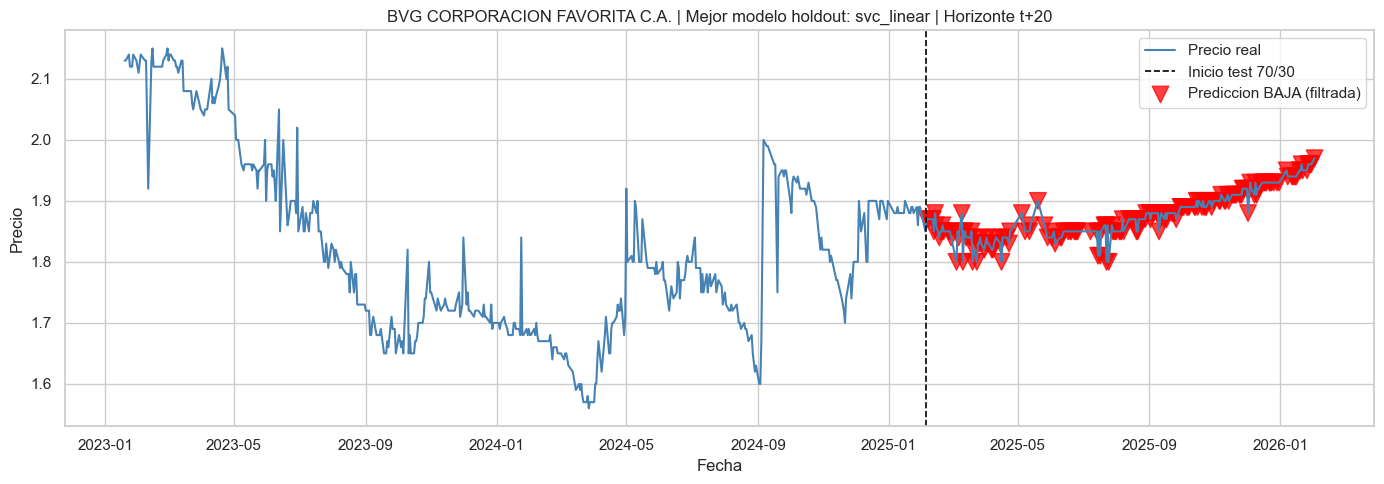

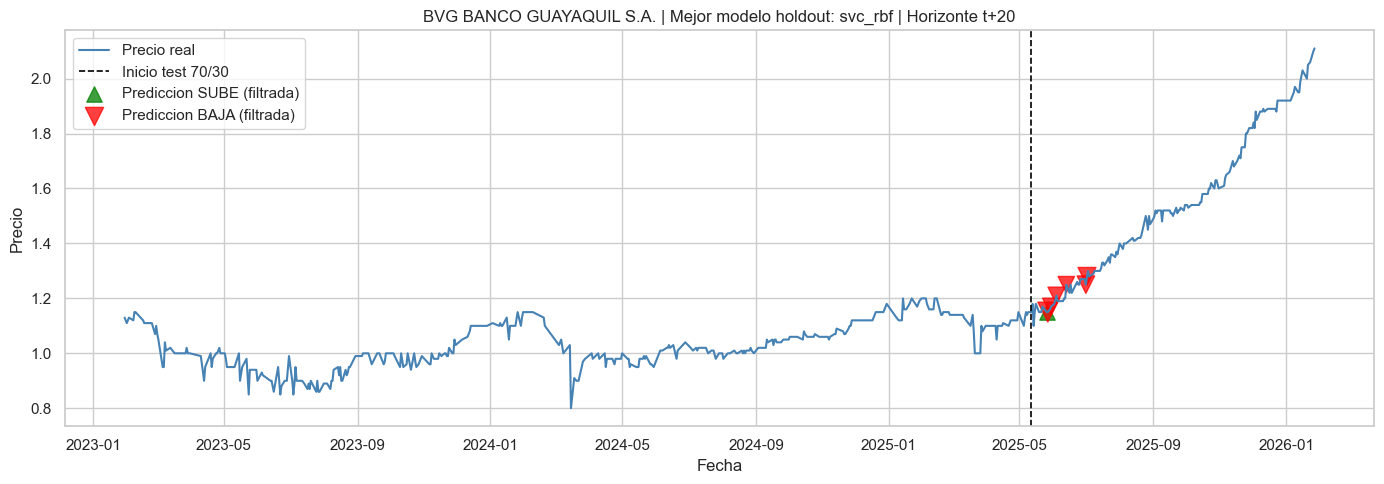

In [8]:
for empresa in empresas_objetivo:
    d_emp = df_model[df_model['empresa'] == empresa].copy().sort_values('fecha').reset_index(drop=True)
    if len(d_emp) < 130:
        continue

    train, test = temporal_split(d_emp, frac=0.7)
    split_date = test['fecha'].min()

    d_holdout = holdout_df[holdout_df['empresa'] == empresa].copy()
    d_holdout_svc = d_holdout[d_holdout['model'].isin(['svc_linear', 'svc_rbf'])].copy()
    if d_holdout_svc.empty:
        continue

    best_model = d_holdout_svc.sort_values(['f1_f', 'f1'], ascending=False).iloc[0]['model']
    pred = holdout_signals_df[(holdout_signals_df['empresa'] == empresa) & (holdout_signals_df['model'] == best_model)].copy()
    pred = pred[pd.notna(pred['y_pred_filtered'])].copy()

    up = pred[pred['y_pred_filtered'] == 1].copy()
    down = pred[pred['y_pred_filtered'] == 0].copy()

    plt.figure(figsize=(14, 5))
    plt.plot(d_emp['fecha'], d_emp['precio_trade_day'], color='steelblue', linewidth=1.5, label='Precio real')
    plt.axvline(split_date, color='black', linestyle='--', linewidth=1.2, label='Inicio test 70/30')

    if not up.empty:
        size_up = 40 + 260 * (up['confidence'] - 0.5).clip(lower=0) * 2
        plt.scatter(up['fecha'], up['precio_trade_day'], s=size_up, marker='^', color='green', alpha=0.75, label='Prediccion SUBE (filtrada)')

    if not down.empty:
        size_down = 40 + 260 * (down['confidence'] - 0.5).clip(lower=0) * 2
        plt.scatter(down['fecha'], down['precio_trade_day'], s=size_down, marker='v', color='red', alpha=0.75, label='Prediccion BAJA (filtrada)')

    plt.title(f'BVG {empresa} | Mejor modelo holdout: {best_model} | Horizonte t+20')
    plt.xlabel('Fecha')
    plt.ylabel('Precio')
    plt.legend(loc='best')
    plt.tight_layout()
    plt.show()

## 9) Analisis final critico (automatizado)

In [9]:
print('=== ANALISIS FINAL V3 ===')
final_rows = []

for empresa in holdout_df['empresa'].unique():
    d = holdout_df[holdout_df['empresa'] == empresa].copy()
    svc = d[d['model'].isin(['svc_linear', 'svc_rbf'])].sort_values(['f1_f', 'f1'], ascending=False).iloc[0]
    base = d[d['model'].isin(['baseline_majority', 'baseline_sign_prev'])].sort_values(['f1_f', 'f1'], ascending=False).iloc[0]

    improve_baseline = (svc['f1'] > base['f1']) and (svc['accuracy'] > base['accuracy'])

    if 'wf_summary' in globals() and not wf_df.empty:
        sw = wf_summary[(wf_summary['empresa'] == empresa) & (wf_summary['model'] == svc['model'])]
        bw = wf_summary[(wf_summary['empresa'] == empresa) & (wf_summary['model'] == base['model'])]
        if not sw.empty and not bw.empty:
            sw = sw.iloc[0]
            bw = bw.iloc[0]
            consistency = (sw['acc_mean'] > bw['acc_mean']) and (sw['f1_mean'] > bw['f1_mean'])
            stable = (sw['acc_std'] <= 0.10) and (sw['f1_std'] <= 0.10)
        else:
            consistency = False
            stable = False
    else:
        consistency = False
        stable = False

    filter_help = pd.notna(svc['accuracy_f']) and pd.notna(svc['f1_f']) and (svc['accuracy_f'] > svc['accuracy']) and (svc['f1_f'] > svc['f1'])
    usable = improve_baseline and consistency and stable and (pd.notna(svc['coverage']) and svc['coverage'] >= 0.35)

    print('')
    print(f'Empresa: {empresa}')
    print(f"- Mejor SVC: {svc['model']}")
    print(f"- Baseline de referencia: {base['model']}")
    print(f"- Delta holdout F1: {float(svc['f1'] - base['f1']):.4f}")
    print(f"- Delta holdout Accuracy: {float(svc['accuracy'] - base['accuracy']):.4f}")
    print(f"- Coverage filtro prob.: {float(svc['coverage']) if pd.notna(svc['coverage']) else np.nan:.3f}")
    print('Respuestas criticas:')
    print(f"1) El modelo supera baseline?: {'SI' if improve_baseline else 'NO'}")
    print(f"2) La mejora es consistente?: {'SI' if consistency else 'NO'}")
    print(f"3) Hay evidencia real de senal?: {'SI' if (improve_baseline and consistency) else 'DEBIL/NO'}")
    print(f"4) Menos predicciones = mejor calidad?: {'SI' if filter_help else 'NO/PARCIAL'}")
    print(f"5) Usable en sistema real?: {'SI' if usable else 'NO'}")

    final_rows.append({
        'empresa': empresa,
        'best_svc': svc['model'],
        'best_baseline': base['model'],
        'delta_f1_holdout': float(svc['f1'] - base['f1']),
        'delta_acc_holdout': float(svc['accuracy'] - base['accuracy']),
        'coverage_best_svc': float(svc['coverage']) if pd.notna(svc['coverage']) else np.nan,
        'improve_baseline_flag': 'yes' if improve_baseline else 'no',
        'consistency_flag': 'yes' if consistency else 'no',
        'stability_flag': 'yes' if stable else 'no',
        'filter_help_flag': 'yes' if filter_help else 'no',
        'usable_real_system_flag': 'yes' if usable else 'no'
    })

final_summary_df = pd.DataFrame(final_rows)
print('\n=== TABLA FINAL V3 ===')
display(final_summary_df)

print('\nConclusiones globales del rediseño (horizonte mensual + umbral target):')
if not final_summary_df.empty:
    n_improve = int((final_summary_df['improve_baseline_flag'] == 'yes').sum())
    n_usable = int((final_summary_df['usable_real_system_flag'] == 'yes').sum())
    print(f'- Cambio a horizonte mensual mejora senal en {n_improve}/{len(final_summary_df)} empresas frente a baseline.')
    print('- El umbral del target ayuda a reducir ambiguedad, pero puede bajar muestra util y estabilidad.')
    print(f'- Usabilidad real actual: {n_usable}/{len(final_summary_df)} empresas cumplen criterio estricto.')
else:
    print('- No hay evidencia suficiente por muestra tras filtros. Necesario ampliar historial o relajar diseno.')

=== ANALISIS FINAL V3 ===

Empresa: CORPORACION FAVORITA C.A.
- Mejor SVC: svc_linear
- Baseline de referencia: baseline_majority
- Delta holdout F1: 0.0000
- Delta holdout Accuracy: 0.0000
- Coverage filtro prob.: 1.000
Respuestas criticas:
1) El modelo supera baseline?: NO
2) La mejora es consistente?: SI
3) Hay evidencia real de senal?: DEBIL/NO
4) Menos predicciones = mejor calidad?: NO/PARCIAL
5) Usable en sistema real?: NO

Empresa: BANCO GUAYAQUIL S.A.
- Mejor SVC: svc_rbf
- Baseline de referencia: baseline_majority
- Delta holdout F1: -0.0365
- Delta holdout Accuracy: -0.0705
- Coverage filtro prob.: 0.045
Respuestas criticas:
1) El modelo supera baseline?: NO
2) La mejora es consistente?: SI
3) Hay evidencia real de senal?: DEBIL/NO
4) Menos predicciones = mejor calidad?: NO/PARCIAL
5) Usable en sistema real?: NO

=== TABLA FINAL V3 ===


,empresa,best_svc,best_baseline,delta_f1_holdout,delta_acc_holdout,coverage_best_svc,improve_baseline_flag,consistency_flag,stability_flag,filter_help_flag,usable_real_system_flag
0,CORPORACION FAVORITA C.A.,svc_linear,baseline_majority,0.000000,0.000000,1.000000,no,yes,no,no,no
1,BANCO GUAYAQUIL S.A.,svc_rbf,baseline_majority,-0.036545,-0.070513,0.044872,no,yes,no,no,no



Conclusiones globales del rediseño (horizonte mensual + umbral target):
- Cambio a horizonte mensual mejora senal en 0/2 empresas frente a baseline.
- El umbral del target ayuda a reducir ambiguedad, pero puede bajar muestra util y estabilidad.
- Usabilidad real actual: 0/2 empresas cumplen criterio estricto.
